In [2]:
import sys
from pathlib import Path
repo_root = Path().resolve().parent  
sys.path.append(str(repo_root))

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.data.Segment_Slicer import SegmentSlicer
from sklearn.metrics import classification_report, confusion_matrix
SegmentSlicer = SegmentSlicer()

In [4]:
df= pd.read_parquet(repo_root / 'data' / 'processed' / 'reunion_segments_cleaned.parquet')

In [5]:
Train, Test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['activity_type'])
Train, Val = train_test_split(Train, test_size=0.25, random_state=42, stratify=Train['activity_type'])
print(f"Train: {len(Train)}, Val: {len(Val)}, Test: {len(Test)}")

Train: 2860, Val: 954, Test: 954


In [6]:
# Séparer Ride et Run
Train_ride = Train[Train['activity_type'] == 'Ride'].copy()
Train_run = Train[Train['activity_type'] == 'Run'].copy()

Val_ride = Val[Val['activity_type'] == 'Ride'].copy()
Val_run = Val[Val['activity_type'] == 'Run'].copy()

Test_ride = Test[Test['activity_type'] == 'Ride'].copy()
Test_run = Test[Test['activity_type'] == 'Run'].copy()

In [7]:
Train_Val_Test_ride = pd.concat([Train_ride, Val_ride, Test_ride], ignore_index=True)
Train_Val_Test_run = pd.concat([Train_run, Val_run, Test_run], ignore_index=True)

In [8]:
print(f"Train Ride: {len(Train_ride)}, Run: {len(Train_run)}")
print(f"Val Ride: {len(Val_ride)}, Run: {len(Val_run)}")
print(f"Test Ride: {len(Test_ride)}, Run: {len(Test_run)}")

Train Ride: 1360, Run: 1500
Val Ride: 453, Run: 501
Test Ride: 453, Run: 501


In [18]:
sections_dict = {}
for idx, row in Train_Val_Test_ride.iterrows():
    segment_id = row['segment_id']
    # Charger altitude_profile, distance_profile, coordinates
    sections = SegmentSlicer.cut_segment(row['altitude_profile'], row['distance_profile'], row['coordinates'])
    sections_dict[segment_id] = sections

KeyboardInterrupt: 

In [10]:
class T1SegmentDetector:
    """
    Détecte automatiquement les segments T1 (route lisse) avec plusieurs critères.
    """
    
    def __init__(self):
        self.road_keywords = None
        self.trail_keywords = None
        
    def detect_t1_segments(self, df, sections_dict, confidence_threshold='medium'):
        """
        Détecte les segments T1 avec un score de confiance.
        
        Returns:
            - df avec colonnes: is_T1_predicted, T1_confidence_score, T1_reasons
        """
        
        df = df.copy()
        
        print("\n" + "="*60)
        print("DÉTECTION AUTOMATIQUE DES SEGMENTS T1")
        print("="*60)
        
        # Initialiser les colonnes
        df['T1_score'] = 0.0
        df['T1_reasons'] = ''
        
        # Critère 1: Nom du segment
        print("\n1. Analyse des noms...")
        name_scores = df.apply(lambda row: self._score_from_name(row['name']), axis=1)
        df['T1_score'] += name_scores
        
        # Critère 2: Profil d'élévation (régularité)
        print("2. Analyse du profil d'élévation...")
        elevation_scores = df.apply(
            lambda row: self._score_from_elevation_profile(
                row['altitude_profile'], 
                row['distance_profile']
            ), 
            axis=1
        )
        df['T1_score'] += elevation_scores
        
        # Critère 3: Sections (variance de grade)
        print("3. Analyse des sections...")
        section_scores = []
        for idx, row in df.iterrows():
            if row['segment_id'] in sections_dict:
                score = self._score_from_sections(sections_dict[row['segment_id']])
            else:
                score = 0
            section_scores.append(score)
        df['T1_score'] += section_scores
        
        # Critère 4: Ratio de vitesse (comparaison avec segments similaires)
        print("4. Analyse des vitesses relatives...")
        speed_scores = self._score_from_speed_comparison(df)
        df['T1_score'] += speed_scores
        
        # Normaliser le score (0-10)
        max_possible_score = 4.0  # 4 critères × max 1.0 chacun
        df['T1_confidence_score'] = (df['T1_score'] / max_possible_score) * 10
        
        # Définir le seuil
        thresholds = {
            'high': 7.0,    # Très confiant
            'medium': 5.5,  # Confiance moyenne
            'low': 4.0      # Peu confiant mais possible
        }
        
        threshold = thresholds[confidence_threshold]
        df['is_T1_predicted'] = df['T1_confidence_score'] >= threshold
        
        # Statistiques
        n_detected = df['is_T1_predicted'].sum()
        print(f"\n" + "="*60)
        print(f"RÉSULTATS:")
        print(f"  Segments détectés comme T1: {n_detected} / {len(df)} ({n_detected/len(df)*100:.1f}%)")
        print(f"  Seuil de confiance: {threshold}")
        print(f"  Distribution des scores:")
        print(f"    0-2:   {(df['T1_confidence_score'] < 2).sum()} segments (clairement trail)")
        print(f"    2-4:   {((df['T1_confidence_score'] >= 2) & (df['T1_confidence_score'] < 4)).sum()} segments")
        print(f"    4-6:   {((df['T1_confidence_score'] >= 4) & (df['T1_confidence_score'] < 6)).sum()} segments (zone grise)")
        print(f"    6-8:   {((df['T1_confidence_score'] >= 6) & (df['T1_confidence_score'] < 8)).sum()} segments")
        print(f"    8-10:  {(df['T1_confidence_score'] >= 8).sum()} segments (très confiant T1)")
        
        return df
    
    # ========================================================
    # CRITÈRE 1: Nom du Segment
    # ========================================================
    
    def _score_from_name(self, name):
        """
        Score basé sur le nom du segment.
        Returns: 0.0 à 1.0
        """
        
        if pd.isna(name):
            return 0.3  # Neutre si pas de nom
        
        name_lower = name.lower()
        
        # Mots-clés ROUTE (T1)
        road_keywords = [
            r'\broute\b', r'\brn\d+\b', r'\bd\d+\b', r'\brte\b',  # Route nationale/départementale
            r'\brd\b', r'\bav\b', r'\bavenue\b',
            r'\brue\b', r'\bchemin goudronn',
            r'\basphalte\b', r'\bbitume\b',
            r'\bcyclable\b', r'\bpiste cyclable\b',
            r'\bvoie verte\b',
            r'\bcol\b.*\broute\b',  # Col par la route
        ]
        
        # Mots-clés TRAIL (NOT T1)
        trail_keywords = [
            r'\btrail\b', r'\bsentier\b', r'\bchemin\b',
            r'\bsingle\b', r'\bsingletrack\b',
            r'\btechnique\b', r'\bcailloux\b', r'\bracines\b',
            r'\bforest\b', r'\bforêt\b', r'\bbois\b',
            r'\bmontagne\b', r'\balpin\b',
            r'\bgr\d+\b',  # GR20, etc.
            r'\bcombe\b', r'\bravin\b',
        ]
        
        # Compter les matches
        road_matches = sum(1 for kw in road_keywords if re.search(kw, name_lower))
        trail_matches = sum(1 for kw in trail_keywords if re.search(kw, name_lower))
        
        # Score
        if road_matches > 0 and trail_matches == 0:
            return 1.0  # Clairement route
        elif road_matches > trail_matches:
            return 0.7  # Probablement route
        elif trail_matches > 0 and road_matches == 0:
            return 0.0  # Clairement trail
        elif trail_matches > road_matches:
            return 0.2  # Probablement trail
        else:
            return 0.3  # Ambigu
    
    # ========================================================
    # CRITÈRE 2: Profil d'Élévation
    # ========================================================
    
    def _score_from_elevation_profile(self, altitude_profile, distance_profile):
        """
        Routes = profil plus régulier, moins de micro-variations.
        Trails = profil chaotique avec beaucoup de petites variations.
        
        Returns: 0.0 à 1.0
        """
        
        if altitude_profile is None or len(altitude_profile) < 10:
            return 0.5  # Neutre
        
        # Calculer la variance du grade sur petites fenêtres
        grades = []
        for i in range(1, len(altitude_profile)):
            dist_diff = distance_profile[i] - distance_profile[i-1]
            alt_diff = altitude_profile[i] - altitude_profile[i-1]
            if dist_diff > 0:
                grade = (alt_diff / dist_diff) * 100
                grades.append(grade)
        
        if len(grades) < 5:
            return 0.5
        
        # Variance locale (fenêtre de 5 points)
        local_variances = []
        window = 5
        for i in range(len(grades) - window):
            local_var = np.var(grades[i:i+window])
            local_variances.append(local_var)
        
        avg_local_variance = np.mean(local_variances) if local_variances else 0
        
        # Routes: variance faible (< 5)
        # Trails: variance élevée (> 20)
        if avg_local_variance < 3:
            return 1.0  # Très régulier = route
        elif avg_local_variance < 8:
            return 0.7  # Assez régulier
        elif avg_local_variance < 15:
            return 0.4  # Moyen
        else:
            return 0.0  # Chaotique = trail
    
    # ========================================================
    # CRITÈRE 3: Sections
    # ========================================================
    
    def _score_from_sections(self, sections):
        """
        Analyse les sections du segment.
        Routes: moins de sections, grade_variance faible.
        Trails: beaucoup de sections, grade_variance élevée.
        
        Returns: 0.0 à 1.0
        """
        
        if not sections or len(sections) == 0:
            return 0.5
        
        # Moyenne de grade_variance
        avg_variance = np.mean([s['grade_variance'] for s in sections])
        
        # Nombre de sections par km
        total_distance_km = sum(s['distance'] for s in sections) / 1000
        sections_per_km = len(sections) / total_distance_km if total_distance_km > 0 else 0
        
        # Score basé sur variance
        if avg_variance < 2:
            variance_score = 1.0
        elif avg_variance < 5:
            variance_score = 0.7
        elif avg_variance < 10:
            variance_score = 0.4
        else:
            variance_score = 0.0
        
        # Score basé sur densité de sections
        if sections_per_km < 2:
            density_score = 1.0  # Peu de sections = régulier
        elif sections_per_km < 4:
            density_score = 0.6
        else:
            density_score = 0.2  # Beaucoup de sections = irrégulier
        
        return (variance_score + density_score) / 2
    
    # ========================================================
    # CRITÈRE 4: Vitesse Relative
    # ========================================================
    
    def _score_from_speed_comparison(self, df):
        """
        Compare la vitesse avec des segments similaires.
        Routes = plus rapides à profil équivalent.
        
        Returns: Series de scores 0.0 à 1.0
        """
        
        # Calculer vitesse moyenne
        df_temp = df.copy()
        df_temp['avg_speed'] = df_temp['distance'] / df_temp['best_time']
        
        # Normaliser par difficulté (distance + elevation)
        df_temp['difficulty'] = df_temp['distance'] / 1000 + df_temp['elevation_gain'] / 10
        df_temp['normalized_speed'] = df_temp['avg_speed'] / df_temp['difficulty']
        
        # Pour chaque segment, comparer avec segments de difficulté similaire
        scores = []
        
        for idx, row in df_temp.iterrows():
            # Trouver segments similaires (±20% en difficulté)
            similar_mask = (
                (df_temp['difficulty'] >= row['difficulty'] * 0.8) &
                (df_temp['difficulty'] <= row['difficulty'] * 1.2) &
                (df_temp.index != idx)
            )
            
            if similar_mask.sum() > 5:
                similar_speeds = df_temp.loc[similar_mask, 'normalized_speed']
                percentile = (similar_speeds < row['normalized_speed']).sum() / len(similar_speeds)
                
                # Si dans le top 30% des vitesses → probablement route
                if percentile > 0.8:
                    scores.append(1.0)
                elif percentile > 0.6:
                    scores.append(0.7)
                elif percentile > 0.4:
                    scores.append(0.5)
                else:
                    scores.append(0.3)
            else:
                scores.append(0.5)  # Pas assez de segments similaires
        
        return pd.Series(scores, index=df.index)

In [11]:
def update_detector_with_manual_labels(detector, df_with_manual_labels, 
                                        target_precision=1.0):
    """
    Utilise les labels manuels pour calibrer les seuils.
    Objectif: Maximiser la précision (éviter les faux positifs).
    
    Précision = TP / (TP + FP)
    → Proportion de segments prédits T1 qui sont vraiment T1
    
    target_precision: 1.0 = 100% précision (aucun faux positif toléré)
                      0.95 = 95% précision (5% de faux positifs OK)
    """
    
    print("\n" + "="*60)
    print("CALIBRATION DU SEUIL POUR PRÉCISION MAXIMALE")
    print("="*60)
    
    # Analyser les erreurs avec le seuil actuel
    false_positives = df_with_manual_labels[
        (df_with_manual_labels['is_T1_predicted'] == True) & 
        (df_with_manual_labels['is_T1_manual'] == False)
    ]
    
    false_negatives = df_with_manual_labels[
        (df_with_manual_labels['is_T1_predicted'] == False) & 
        (df_with_manual_labels['is_T1_manual'] == True)
    ]
    
    true_positives = df_with_manual_labels[
        (df_with_manual_labels['is_T1_predicted'] == True) & 
        (df_with_manual_labels['is_T1_manual'] == True)
    ]
    
    print(f"\nAvec seuil actuel:")
    print(f"  Vrais positifs:  {len(true_positives)}")
    print(f"  Faux positifs:   {len(false_positives)}")
    print(f"  Faux négatifs:   {len(false_negatives)}")
    
    if len(false_positives) > 0:
        print(f"\n  Score moyen des FAUX positifs: {false_positives['T1_confidence_score'].mean():.2f}")
        print(f"  Score min des FAUX positifs:   {false_positives['T1_confidence_score'].min():.2f}")
        print(f"  Score max des FAUX positifs:   {false_positives['T1_confidence_score'].max():.2f}")
    
    if len(false_negatives) > 0:
        print(f"\n  Score moyen des FAUX négatifs: {false_negatives['T1_confidence_score'].mean():.2f}")
        print(f"  Score min des FAUX négatifs:   {false_negatives['T1_confidence_score'].min():.2f}")
        print(f"  Score max des FAUX négatifs:   {false_negatives['T1_confidence_score'].max():.2f}")
    
    # ========================================================
    # TROUVER LE SEUIL POUR PRÉCISION CIBLE
    # ========================================================
    
    print(f"\n" + "="*60)
    print(f"RECHERCHE DU SEUIL POUR PRÉCISION ≥ {target_precision*100:.0f}%")
    print("="*60)
    
    # Tester tous les seuils possibles
    from sklearn.metrics import precision_score, recall_score
    
    # Générer des seuils à tester (de 0 à 10 par pas de 0.1)
    test_thresholds = np.arange(0, 10.5, 0.1)
    
    results = []
    
    for threshold in test_thresholds:
        y_pred = df_with_manual_labels['T1_confidence_score'] >= threshold
        
        # Calculer précision et recall
        if y_pred.sum() > 0:  # Éviter division par 0
            precision = precision_score(df_with_manual_labels['is_T1_manual'], y_pred, zero_division=0)
            recall = recall_score(df_with_manual_labels['is_T1_manual'], y_pred, zero_division=0)
            n_predicted = y_pred.sum()
            
            results.append({
                'threshold': threshold,
                'precision': precision,
                'recall': recall,
                'n_predicted': n_predicted
            })
    
    results_df = pd.DataFrame(results)
    
    # Filtrer pour précision >= target
    acceptable = results_df[results_df['precision'] >= target_precision]
    
    if len(acceptable) == 0:
        print(f"\n⚠️  ATTENTION: Impossible d'atteindre {target_precision*100:.0f}% de précision!")
        print(f"    Meilleure précision possible: {results_df['precision'].max()*100:.1f}%")
        
        # Prendre le meilleur compromis
        best_idx = results_df['precision'].idxmax()
        optimal_threshold = results_df.loc[best_idx, 'threshold']
        final_precision = results_df.loc[best_idx, 'precision']
        final_recall = results_df.loc[best_idx, 'recall']
        n_predicted = results_df.loc[best_idx, 'n_predicted']
        
        print(f"\n    Seuil recommandé: {optimal_threshold:.1f}")
        print(f"    → Précision: {final_precision*100:.1f}%")
        print(f"    → Recall: {final_recall*100:.1f}%")
        print(f"    → Segments détectés: {int(n_predicted)}")
        
    else:
        # Parmi les seuils acceptables, prendre celui avec le meilleur recall
        # (pour maximiser le nombre de T1 détectés tout en gardant précision parfaite)
        best_idx = acceptable['recall'].idxmax()
        optimal_threshold = acceptable.loc[best_idx, 'threshold']
        final_precision = acceptable.loc[best_idx, 'precision']
        final_recall = acceptable.loc[best_idx, 'recall']
        n_predicted = acceptable.loc[best_idx, 'n_predicted']
        
        print(f"\n✓ Seuil optimal trouvé: {optimal_threshold:.1f}")
        print(f"  → Précision: {final_precision*100:.1f}% ({'=' if final_precision == target_precision else '≥'} {target_precision*100:.0f}%)")
        print(f"  → Recall: {final_recall*100:.1f}%")
        print(f"  → Segments détectés comme T1: {int(n_predicted)}")
        
        # Info sur ce qu'on perd en recall
        if target_precision < 1.0:
            perfect_precision = results_df[results_df['precision'] == 1.0]
            if len(perfect_precision) > 0:
                perfect_recall = perfect_precision['recall'].max()
                perfect_n = perfect_precision.loc[perfect_precision['recall'].idxmax(), 'n_predicted']
                print(f"\n  Note: Avec précision 100%, recall serait {perfect_recall*100:.1f}% ({int(perfect_n)} segments)")
    
    # ========================================================
    # VISUALISATION
    # ========================================================
    
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Precision-Recall curve
    axes[0].plot(results_df['threshold'], results_df['precision'], 
                 'b-', linewidth=2, label='Précision')
    axes[0].plot(results_df['threshold'], results_df['recall'], 
                 'g-', linewidth=2, label='Recall')
    axes[0].axvline(optimal_threshold, color='r', linestyle='--', 
                    linewidth=2, label=f'Seuil optimal: {optimal_threshold:.1f}')
    axes[0].axhline(target_precision, color='orange', linestyle=':', 
                    linewidth=2, label=f'Target précision: {target_precision*100:.0f}%')
    axes[0].set_xlabel('Seuil (T1_confidence_score)')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Précision vs Recall en fonction du seuil')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(0, 1.05)
    
    # Plot 2: Nombre de segments détectés
    axes[1].plot(results_df['threshold'], results_df['n_predicted'], 
                 'b-', linewidth=2)
    axes[1].axvline(optimal_threshold, color='r', linestyle='--', 
                    linewidth=2, label=f'Seuil: {optimal_threshold:.1f}')
    axes[1].scatter([optimal_threshold], [n_predicted], 
                   s=200, color='red', zorder=5, 
                   label=f'{int(n_predicted)} segments')
    axes[1].set_xlabel('Seuil (T1_confidence_score)')
    axes[1].set_ylabel('Nombre de segments détectés comme T1')
    axes[1].set_title('Trade-off: Seuil vs Nombre de T1 détectés')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    
    return optimal_threshold

In [12]:
def active_learning_validation(df, n_to_validate=50):
    """
    Sélectionne intelligemment les segments à valider manuellement.
    """
    
    # Stratégie: valider les segments les plus incertains (score proche de 5)
    # + quelques high confidence pour confirmer
    
    uncertain = df[
        (df['T1_confidence_score'] >= 4.5) & 
        (df['T1_confidence_score'] <= 6.5)
    ].sample(min(30, len(df[(df['T1_confidence_score'] >= 4.5) & (df['T1_confidence_score'] <= 6.5)])))
    
    high_conf = df[df['T1_confidence_score'] >= 8].sample(min(10, len(df[df['T1_confidence_score'] >= 8])))
    low_conf = df[df['T1_confidence_score'] <= 2].sample(min(10, len(df[df['T1_confidence_score'] <= 2])))
    
    to_validate = pd.concat([uncertain, high_conf, low_conf])
    
    print(f"\n{len(to_validate)} segments sélectionnés pour validation:")
    print(f"  - {len(uncertain)} incertains (4.5-6.5)")
    print(f"  - {len(high_conf)} haute confiance (≥8)")
    print(f"  - {len(low_conf)} basse confiance (≤2)")
    
    return to_validate

In [13]:
# 1. Détecter les T1
detector = T1SegmentDetector()

df_ride_with_T1 = detector.detect_t1_segments(
    Train_Val_Test_ride, 
    sections_dict,
    confidence_threshold='high'  # 'high', 'medium', ou 'low'
)



DÉTECTION AUTOMATIQUE DES SEGMENTS T1

1. Analyse des noms...
2. Analyse du profil d'élévation...
3. Analyse des sections...
4. Analyse des vitesses relatives...

RÉSULTATS:
  Segments détectés comme T1: 368 / 2266 (16.2%)
  Seuil de confiance: 7.0
  Distribution des scores:
    0-2:   27 segments (clairement trail)
    2-4:   842 segments
    4-6:   703 segments (zone grise)
    6-8:   550 segments
    8-10:  144 segments (très confiant T1)


In [14]:
to_validate = active_learning_validation(df_ride_with_T1)
to_validate = to_validate[["segment_id", "name", "T1_confidence_score", "is_T1_predicted"]].copy()
to_validate.to_csv('priority_validation.csv', index=False)


50 segments sélectionnés pour validation:
  - 30 incertains (4.5-6.5)
  - 10 haute confiance (≥8)
  - 10 basse confiance (≤2)



CALIBRATION DU SEUIL POUR PRÉCISION MAXIMALE

Avec seuil actuel:
  Vrais positifs:  8
  Faux positifs:   0
  Faux négatifs:   33

  Score moyen des FAUX négatifs: 4.91
  Score min des FAUX négatifs:   2.00
  Score max des FAUX négatifs:   6.50

RECHERCHE DU SEUIL POUR PRÉCISION ≥ 100%

✓ Seuil optimal trouvé: 6.5
  → Précision: 100.0% (= 100%)
  → Recall: 22.0%
  → Segments détectés comme T1: 9


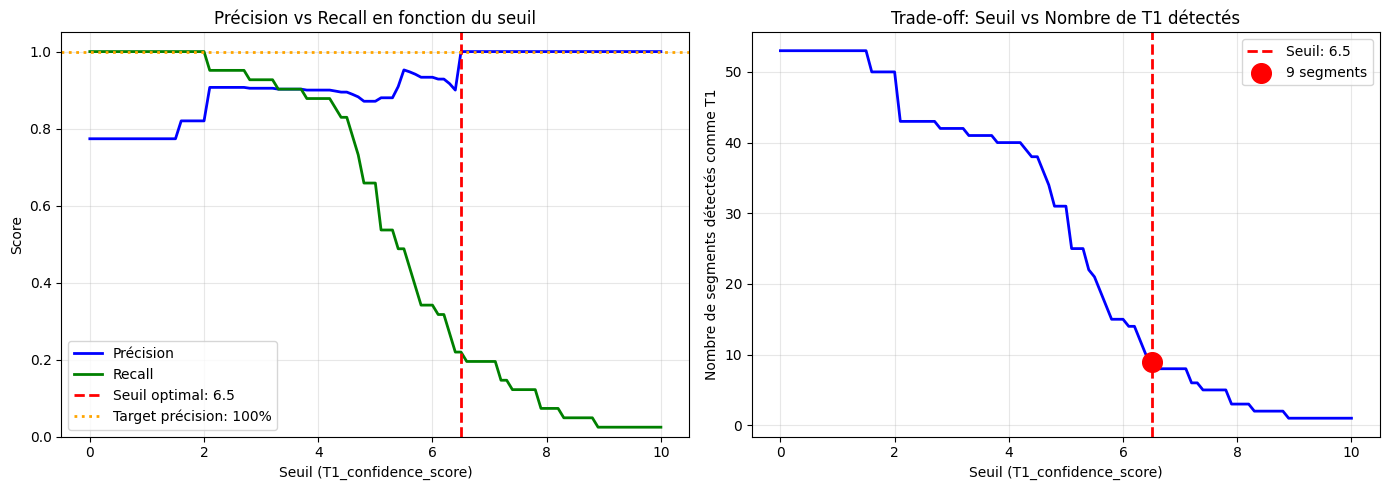

In [15]:
df_validated = pd.read_csv(repo_root / 'data' / 'processed' / 'active_learning_validation.csv')
for idx, row in df_validated.iterrows():
    df_validated.at[idx, "T1_confidence_score"] = df_ride_with_T1[["T1_confidence_score"]][df_ride_with_T1["segment_id"] == row["segment_id"]].values[0]

optimal_threshold = update_detector_with_manual_labels(detector, df_validated)

In [17]:
df_thresholded_7 = df_ride_with_T1.copy()
df_thresholded_7 = df_thresholded_7[df_thresholded_7['T1_confidence_score'] >= 7.0]
df_thresholded_7_csv = df_thresholded_7[["segment_id"]].copy()
df_thresholded_7_csv.loc[:, "technicality"] = np.ones(len(df_thresholded_7_csv), dtype=int)
df_thresholded_7_csv.to_csv('../data/processed/T1_active_learning_threshold_7_ride.csv', index=False)